In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df.shape

(555278, 86)

In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

In [ ]:
df_exclude_object['Label'].value_counts()

0    517582
1     37696
Name: Label, dtype: int64

In [ ]:
df_exclude_object.shape

(555278, 82)

In [ ]:
df_exclude_object.head(5)

,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Label
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,1
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,...,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,1
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,...,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,1
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,...,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0,1
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,...,126016.885411,7.545305e+06,7.545305e+06,7.545305e+06,7.545305e+06,0.0,29200,65160,0,1


In [ ]:
#ingat KNN itu sangat susah dengan fitur yang banyak krn konsepnya itu mengecek titik terdekatnya

from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler.fit(df_exclude_object.drop('Label', axis=1)) #jangan ambil target class yang kita mau predcit

StandardScaler()

In [ ]:
scaled_features = scaler.transform(df_exclude_object.drop('Label', axis=1))

In [ ]:
df_feat = pd.DataFrame(scaled_features, columns = df_exclude_object.columns[:-1]) #:-1 artinya kecuali yang terakhir

In [ ]:
df_feat.head()

,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,-1.403136,-0.359185,-0.069733,-0.007036,-0.010430,-0.026646,-0.020977,-0.343154,-0.366670,-0.362967,...,0.169360,-0.016116,-0.193395,-0.214941,-0.085848,-0.212595,-0.110907,0.963062,1.514442,-0.410759
1,-1.403025,-0.359185,0.062059,-0.007036,-0.010430,-0.026646,-0.020977,-0.344322,-0.367867,-0.364178,...,-0.068402,0.002958,0.656667,0.444544,0.072599,0.588207,-0.110907,0.963062,1.514442,-0.410759
2,-1.402914,-0.359185,0.028455,-0.009192,-0.012562,-0.026646,-0.023116,-0.344285,-0.367830,-0.364139,...,-0.071050,-0.000982,0.469687,0.299483,0.037747,0.412062,-0.110907,0.963062,1.514442,-0.410759
3,-1.402804,-0.359185,0.006738,-0.009192,-0.012562,-0.026646,-0.023116,-0.344234,-0.367778,-0.364087,...,-0.071164,-0.001255,0.347303,0.204537,0.014936,0.296770,-0.110907,0.963062,1.514442,-0.410759
4,-1.402693,-0.359185,-0.014989,-0.009192,-0.010430,-0.026646,-0.023116,-0.344154,-0.367669,-0.363991,...,-0.071046,-0.000913,0.224644,0.109377,-0.007927,0.181219,-0.110907,0.963062,1.514442,-0.410759


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_feat #bisa ji juga scaled_features
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=2)

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [ ]:
pred = knn.predict(X_test)

In [ ]:
pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
#Original imbalance, KNN n=2
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96    155457
           1       0.16      0.05      0.08     11127

    accuracy                           0.92    166584
   macro avg       0.55      0.52      0.52    166584
weighted avg       0.88      0.92      0.90    166584



In [ ]:
#Original imbalance, KNN n=1
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94    155457
           1       0.14      0.15      0.14     11127

    accuracy                           0.88    166584
   macro avg       0.54      0.54      0.54    166584
weighted avg       0.89      0.88      0.88    166584



In [ ]:
print(confusion_matrix(y_test, pred))

[[144790  10667]
 [  9427   1700]]


#Undersampling

<AxesSubplot:ylabel='Label'>

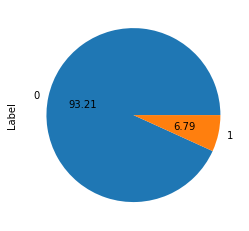

In [ ]:
y.value_counts().plot.pie(autopct='%.2f')

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

Text(0.5, 1.0, 'Under Sampling')

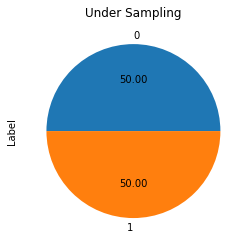

In [ ]:
rus = RandomUnderSampler(sampling_strategy=1)
X_res, y_res = rus.fit_resample(X_train, y_train)
ax = y_res.value_counts().plot.pie(autopct='%.2f')
ax.set_title('Under Sampling')

In [ ]:
y_res.value_counts()

0    26569
1    26569
Name: Label, dtype: int64

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
knn.fit(X_res, y_res)

KNeighborsClassifier(n_neighbors=2)

In [ ]:
pred = knn.predict(X_test)

In [ ]:
pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
#Undersampling, KNN n=2
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93    155457
           1       0.33      0.74      0.46     11127

    accuracy                           0.88    166584
   macro avg       0.66      0.82      0.70    166584
weighted avg       0.94      0.88      0.90    166584



In [ ]:
#Undersampling, KNN n=1
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.87      0.93    155457
           1       0.32      0.83      0.46     11127

    accuracy                           0.87    166584
   macro avg       0.65      0.85      0.69    166584
weighted avg       0.94      0.87      0.90    166584



In [ ]:
print(confusion_matrix(y_test, pred))

[[135704  19753]
 [  1867   9260]]


#Cari N dalam KNN terbaik

In [ ]:
error_rate=[]

for i in range(1, 10):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_res, y_res)
  pred_i = knn.predict(X_test)
  error_rate.append(np.mean(pred_i != y_test))


Text(0, 0.5, 'Error Rate')

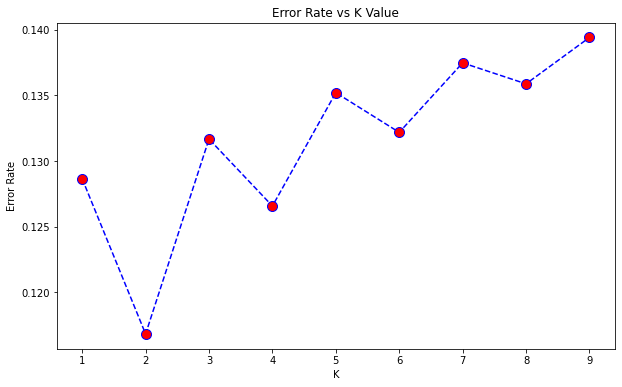

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(range(1,10), error_rate, color = 'blue', linestyle = '--', marker = 'o', markerfacecolor = 'red', markersize = 10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')